In [2]:
import hdbscan
from hdbscan import HDBSCAN
from pymethylprocess.MethylationDataTypes import MethylationArray
from pymethylprocess.general_machine_learning import MachineLearning
import pandas as pd, numpy as np
from sklearn.decomposition import PCA
from sklearn import metrics
import matplotlib, matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

import matplotlib.ticker as ticker
from itertools import cycle

import seaborn as sns
from seaborn import cubehelix_palette
sns.set()

In [146]:
def create_roc_curve(Y, probabilities, class_lookup, title, ax):
    
    n_classes = Y.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    ax.set_title(title)
    if n_classes == 4:
        colors = cycle(['coral', 'gold', 'green', 'cornflowerblue'])
    else:
        colors = cycle(['orange', 'red', 'aqua', 'black'])
    for i, color in zip(range(n_classes), colors):
        fpr[i], tpr[i], _ = metrics.roc_curve(Y[:, i], probabilities[:, i])
        roc_auc[i] = metrics.auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], color=color,
                label='ROC curve of class {0} (area = {1:0.2f})'.format(
                    class_lookup[i], roc_auc[i]))
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_xlabel('False Positive Rate', fontsize=15)
    ax.set_ylabel('True Positive Rate', fontsize=15)
    ax.legend(loc="lower right", fontsize=12)
    # plt.show()

In [102]:
def print_accuracy_and_classification_report(labels, prediction):
    print('Cross validation accuracy:')
    print('\t', metrics.accuracy_score(labels, prediction))
    print('\nCross validation classification report\n')
    print(metrics.classification_report(labels, prediction))

In [4]:
train_methyl_array=MethylationArray.from_pickle("train_methyl_array.pkl")
val_methyl_array=MethylationArray.from_pickle("val_methyl_array.pkl")
test_methyl_array=MethylationArray.from_pickle("test_methyl_array.pkl")

In [5]:
train_methyl_array.pheno.disease.unique()

array(['Melanoma brain metastasis',
       'Uncertain primary tumor brain metastasis',
       'Breast cancer brain metastasis', 'Lung cancer brain metastasis'],
      dtype=object)

## Dimension reduction

In [8]:
whole=MethylationArray.from_pickle("methyl_array.pkl")
MethylationArray.feature_select(whole, n_top_cpgs=55)

apply back to the splited data

In [10]:
train_methyl_array.beta = train_methyl_array.beta[whole.beta.columns]
val_methyl_array.beta = val_methyl_array.beta[whole.beta.columns]
test_methyl_array.beta = test_methyl_array.beta[whole.beta.columns]

In [91]:
X_train=train_methyl_array.beta
X_val=val_methyl_array.beta
X_test=test_methyl_array.beta

In [89]:
print("Length of X_train : " + str(len(X_train)) + ", X_val : " + str(len(X_val)) + ", X_test : " + str(len(X_test)))

Length of X_train : 59, X_val : 8, X_test : 17


In [92]:
Y_train=train_methyl_array.pheno['disease'].to_frame()
Y_val=val_methyl_array.pheno['disease'].to_frame()
Y_test=test_methyl_array.pheno['disease'].to_frame()

In [93]:
Y_train=Y_train[:59]
Y_val=Y_val[:8]
Y_test=Y_test[:17]

In [95]:
Y_train['disease'] = Y_train['disease'].apply(lambda x: "M" if  'Melanoma' in x else x)
Y_train['disease'] = Y_train['disease'].apply(lambda x: "U" if  'Uncertain' in x else x)
Y_train['disease'] = Y_train['disease'].apply(lambda x: "B" if  'Breast' in x else x)
Y_train['disease'] = Y_train['disease'].apply(lambda x: "L" if  'Lung' in x else x)

Y_val['disease'] = Y_val['disease'].apply(lambda x: "M" if  'Melanoma' in x else x)
Y_val['disease'] = Y_val['disease'].apply(lambda x: "U" if  'Uncertain' in x else x)
Y_val['disease'] = Y_val['disease'].apply(lambda x: "B" if  'Breast' in x else x)
Y_val['disease'] = Y_val['disease'].apply(lambda x: "L" if  'Lung' in x else x)

Y_test['disease'] = Y_test['disease'].apply(lambda x: "M" if  'Melanoma' in x else x)
Y_test['disease'] = Y_test['disease'].apply(lambda x: "U" if  'Uncertain' in x else x)
Y_test['disease'] = Y_test['disease'].apply(lambda x: "B" if  'Breast' in x else x)
Y_test['disease'] = Y_test['disease'].apply(lambda x: "L" if  'Lung' in x else x)

In [96]:
X_train_ = X_train.values
X_val_ = X_val.values
X_test_ = X_test.values

Y_train_ = Y_train['disease'].values
Y_val_ = Y_val['disease'].values
Y_test_ = Y_test['disease'].values

# Classification

In [75]:
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict

In [97]:
enc = preprocessing.MultiLabelBinarizer()
Y_one_hot = enc.fit_transform(Y_train_)

In [98]:
print(list(enc.classes_))

['B', 'L', 'M', 'U']


## RF

In [100]:
from sklearn.ensemble import RandomForestClassifier

estimator = RandomForestClassifier(n_estimators=1000)

##### Evaluation

In [111]:
rf = estimator.fit(X_train_, Y_train_)

In [112]:
test_prob_rf = rf.predict_proba(X_test_)
Y_test_labels = enc.transform(Y_test_)

/home/minie/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_ranking.py:813: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  UndefinedMetricWarning)


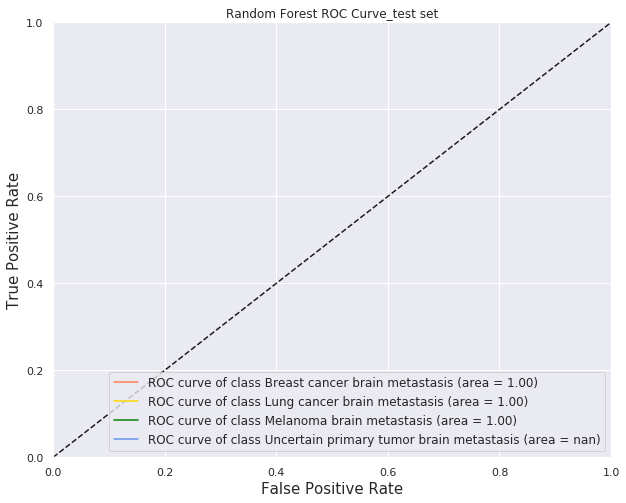

In [114]:
class_lookup = {0: 'Breast cancer brain metastasis', 
                1: 'Lung cancer brain metastasis', 
                2: 'Melanoma brain metastasis', 
                3: 'Uncertain primary tumor brain metastasis'}

fig, ax = plt.subplots(figsize=(10,8))
create_roc_curve(Y_test_labels, test_prob_rf, class_lookup, 'Random Forest ROC Curve_test set', ax)

In [117]:
y_pred_train = estimator.predict(X_train_)
y_pred_val = estimator.predict(X_val_)
y_pred_test = estimator.predict(X_test_)

In [120]:
train_pred = enc.transform(y_pred_train)
val_pred = enc.transform(y_pred_val)
test_pred = enc.transform(y_pred_test)

In [121]:
Y_val_labels = enc.transform(Y_val_)

In [122]:
print(" ------ Training set ------")
print_accuracy_and_classification_report(Y_one_hot, train_pred)
print(" ------ Validation set ------")
print_accuracy_and_classification_report(Y_val_labels, val_pred)
print(" ------ Test set ------")
print_accuracy_and_classification_report(Y_test_labels, test_pred)

 ------ Training set ------
Cross validation accuracy:
	 1.0

Cross validation classification report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00         4

   micro avg       1.00      1.00      1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59
 samples avg       1.00      1.00      1.00        59

 ------ Validation set ------
Cross validation accuracy:
	 0.875

Cross validation classification report

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         0

   micro avg       0.88      0.

/home/minie/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/minie/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


[[7 0 0]
 [0 1 0]
 [0 0 9]]


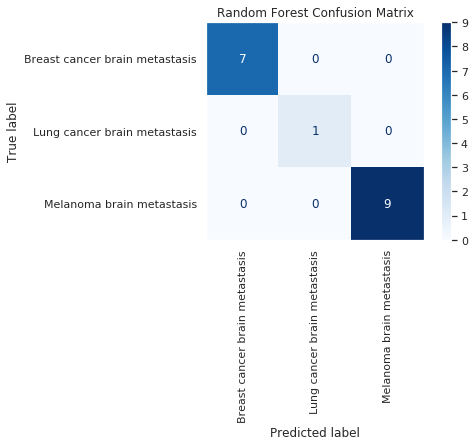

In [151]:
from sklearn.metrics import plot_confusion_matrix

class_names = ['Breast cancer brain metastasis', 
                'Lung cancer brain metastasis', 
                'Melanoma brain metastasis', 
                'Uncertain primary tumor brain metastasis']

disp = plot_confusion_matrix(estimator, X_test_, Y_test_,
                            display_labels=class_names,
                            cmap=plt.cm.Blues, xticks_rotation='vertical')

disp.ax_.set_title("Random Forest Confusion Matrix")

print(disp.confusion_matrix)
plt.grid(False)
plt.show()

In [179]:
rf.feature_importances_

array([0.05125767, 0.00689772, 0.01020682, 0.00729318, 0.00272207,
       0.05010997, 0.00848794, 0.00906714, 0.03190254, 0.01798702,
       0.01027544, 0.00555791, 0.01548716, 0.05487671, 0.03088673,
       0.06802196, 0.01972391, 0.00434853, 0.02277359, 0.01399194,
       0.01472709, 0.00754695, 0.0286434 , 0.04155917, 0.01062848,
       0.03634571, 0.00357856, 0.01858715, 0.02558374, 0.00364481,
       0.0157663 , 0.00463575, 0.01850744, 0.00340515, 0.00653952,
       0.00283508, 0.01555971, 0.01344952, 0.0150125 , 0.05345799,
       0.03001595, 0.00825995, 0.01482134, 0.0102716 , 0.01377788,
       0.00404127, 0.04250182, 0.0050534 , 0.0154739 , 0.00552017,
       0.00940736, 0.02096459, 0.00580453, 0.02574571, 0.00645056])

##### Feature importance

In [181]:
# Fix which numbers correspond to which variables
feature_importances = pd.DataFrame(rf.feature_importances_,index =train_methyl_array.beta.columns,
columns=['importance']).sort_values('importance', ascending=False) 

feature_importances = feature_importances[:10]

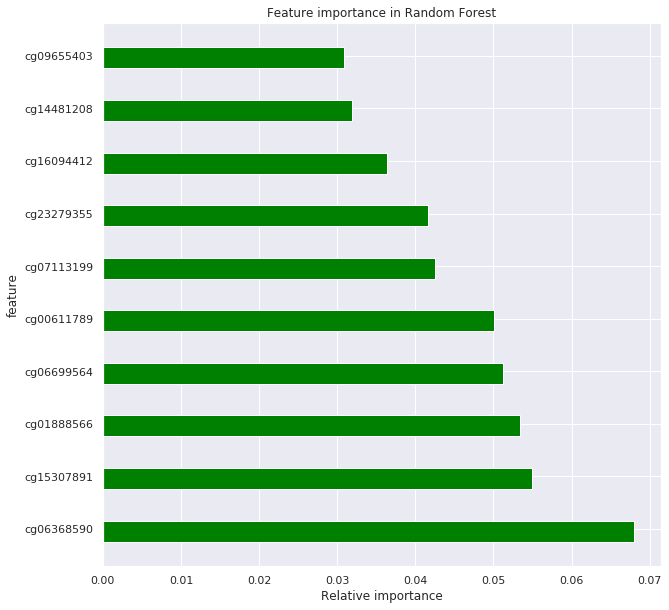

<Figure size 360x360 with 0 Axes>

In [183]:
import matplotlib. pyplot as plt
#modelname.feature_importance
x  = feature_importances.importance
col = feature_importances.importance.index

#plot
fig, ax = plt.subplots() 
width = 0.4 # the width of the bars 
ind = np.arange(len(x)) # the x locations for the groups
ax.barh(ind, x, width, color="green")
ax.set_yticks(ind+width/10)
ax.set_yticklabels(col, minor=False)
plt.title("Feature importance in Random Forest")
plt.xlabel("Relative importance")
plt.ylabel("feature") 
plt.figure(figsize=(5,5))
fig.set_size_inches(10, 10, forward=True)

## SVM

In [123]:
svm_enc = preprocessing.LabelEncoder()

In [126]:
Y_train_labels_svm = svm_enc.fit_transform(Y_train_)
Y_val_labels_svm = svm_enc.transform(Y_val_)
Y_test_labels_svm = svm_enc.transform(Y_test_)

In [186]:
from sklearn.svm import SVC 

model = SVC(kernel = 'linear', probability=True)

In [187]:
svm = model.fit(X_train_, Y_train_)

In [188]:
test_prob_svm = svm.predict_proba(X_test_)

##### Evaluation

/home/minie/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_ranking.py:813: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  UndefinedMetricWarning)


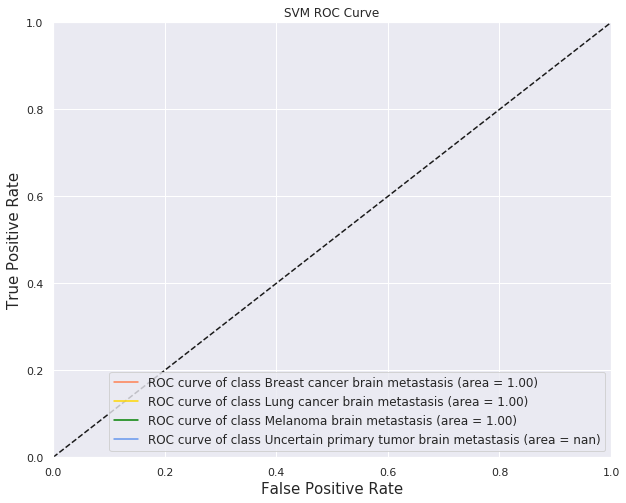

In [189]:
class_lookup = {0: 'Breast cancer brain metastasis', 
                1: 'Lung cancer brain metastasis', 
                2: 'Melanoma brain metastasis', 
                3: 'Uncertain primary tumor brain metastasis'}

Y_test_labels_roc_svm = enc.transform(Y_test_)
fig, ax = plt.subplots(figsize=(10,8))
create_roc_curve(Y_test_labels_roc_svm, test_prob_svm, class_lookup, 'SVM ROC Curve', ax)

In [190]:
y_pred_train_svm = model.predict(X_train_)
y_pred_val_svm = model.predict(X_val_)
y_pred_test_svm = model.predict(X_test_)

train_pred_svm = svm_enc.transform(y_pred_train_svm)
val_pred_svm = svm_enc.transform(y_pred_val_svm)
test_pred_svm = svm_enc.transform(y_pred_test_svm)

print(" ------ Training set ------")
print_accuracy_and_classification_report(Y_train_labels_svm, train_pred_svm)
print(" ------ Validation set ------")
print_accuracy_and_classification_report(Y_val_labels_svm, val_pred_svm)
print(" ------ Test set ------")
print_accuracy_and_classification_report(Y_test_labels_svm, test_pred_svm)

 ------ Training set ------
Cross validation accuracy:
	 1.0

Cross validation classification report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00         4

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59

 ------ Validation set ------
Cross validation accuracy:
	 0.75

Cross validation classification report

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      0.33      0.50         3
           2       1.00      1.00      1.00         3

    accuracy                           0.75         8
   macro avg       0.83      0.78      0.72         8
weighted avg       0.88      0.7

[[7 0 0]
 [0 1 0]
 [0 0 9]]


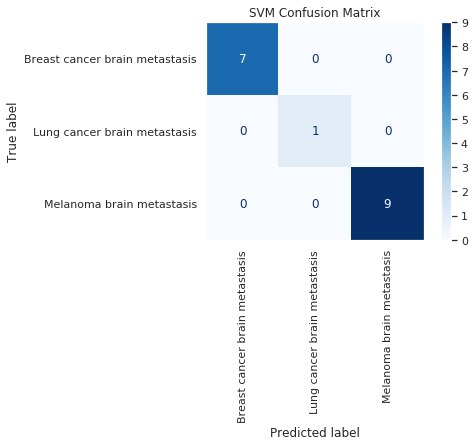

In [164]:
class_names = ['Breast cancer brain metastasis', 
                'Lung cancer brain metastasis', 
                'Melanoma brain metastasis', 
                'Uncertain primary tumor brain metastasis']

disp = plot_confusion_matrix(model, X_test_, Y_test_,
                            display_labels=class_names,
                            cmap=plt.cm.Blues, xticks_rotation='vertical')

disp.ax_.set_title("SVM Confusion Matrix")

print(disp.confusion_matrix)
plt.grid(False)
plt.show()

##### Feature Importance 

In [194]:
# Fix which numbers correspond to which variables
feature_importances_svm = pd.DataFrame(svm.coef_[0], index =train_methyl_array.beta.columns,
columns=['importance']).sort_values('importance', ascending=False) 

feature_importances_svm = feature_importances_svm[:10]

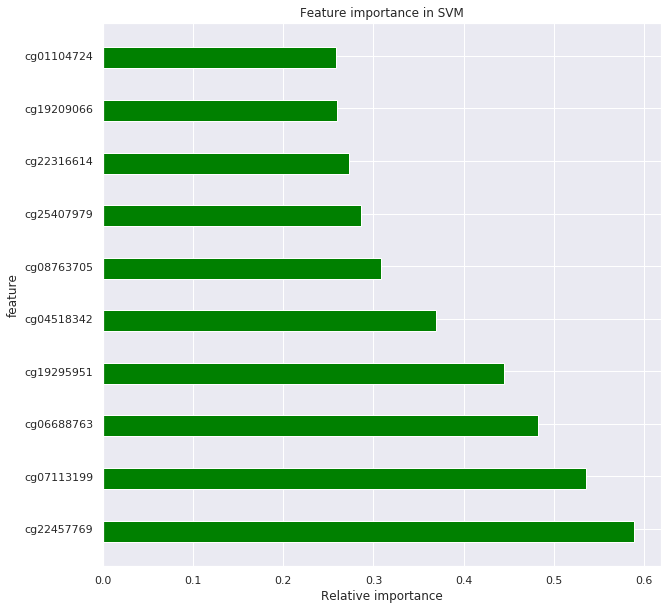

<Figure size 360x360 with 0 Axes>

In [208]:
import matplotlib. pyplot as plt
#modelname.feature_importance
x  = feature_importances_svm.importance
col = feature_importances_svm.importance.index

#plot
fig, ax = plt.subplots() 
width = 0.4 # the width of the bars 
ind = np.arange(len(x)) # the x locations for the groups
ax.barh(ind, x, width, color="green")
ax.set_yticks(ind+width/10)
ax.set_yticklabels(col, minor=False)
plt.title("Feature importance in SVM")
plt.xlabel("Relative importance")
plt.ylabel("feature") 
plt.figure(figsize=(5,5))
fig.set_size_inches(10, 10, forward=True)

## KNN

In [196]:
from sklearn.neighbors import KNeighborsClassifier

In [198]:
knn_est = KNeighborsClassifier(n_neighbors=9)

In [199]:
knn = knn_est.fit(X_train_, Y_train_)
test_prob_knn = knn.predict_proba(X_test_)

##### Evaluation

/home/minie/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_ranking.py:813: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  UndefinedMetricWarning)


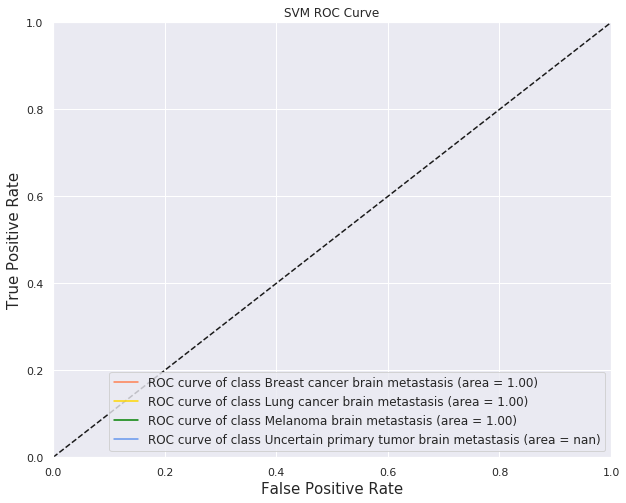

In [200]:
class_lookup = {0: 'Breast cancer brain metastasis', 
                1: 'Lung cancer brain metastasis', 
                2: 'Melanoma brain metastasis', 
                3: 'Uncertain primary tumor brain metastasis'}

Y_test_labels_roc_knn = enc.transform(Y_test_)
fig, ax = plt.subplots(figsize=(10,8))
create_roc_curve(Y_test_labels_roc_knn, test_prob_knn, class_lookup, 'SVM ROC Curve', ax)

In [202]:
Y_train_labels_knn = enc.transform(Y_train_)
Y_val_labels_knn = enc.transform(Y_val_)
Y_test_labels_knn = enc.transform(Y_test_)

In [203]:
y_pred_train_knn = knn_est.predict(X_train_)
y_pred_val_knn = knn_est.predict(X_val_)
y_pred_test_knn = knn_est.predict(X_test_)

train_pred_knn = enc.transform(y_pred_train_knn)
val_pred_knn = enc.transform(y_pred_val_knn)
test_pred_knn = enc.transform(y_pred_test_knn)

print(" ------ Training set ------")
print_accuracy_and_classification_report(Y_train_labels_knn, train_pred_knn)
print(" ------ Validation set ------")
print_accuracy_and_classification_report(Y_val_labels_knn, val_pred_knn)
print(" ------ Test set ------")
print_accuracy_and_classification_report(Y_test_labels_knn, test_pred_knn)

 ------ Training set ------
Cross validation accuracy:
	 0.9152542372881356

Cross validation classification report

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        21
           1       0.80      0.92      0.86        13
           2       1.00      1.00      1.00        21
           3       0.00      0.00      0.00         4

   micro avg       0.92      0.92      0.92        59
   macro avg       0.68      0.73      0.70        59
weighted avg       0.86      0.92      0.88        59
 samples avg       0.92      0.92      0.92        59

 ------ Validation set ------
Cross validation accuracy:
	 0.875

Cross validation classification report

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         0

   micro avg    

/home/minie/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/minie/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


[[7 0 0]
 [0 1 0]
 [0 0 9]]


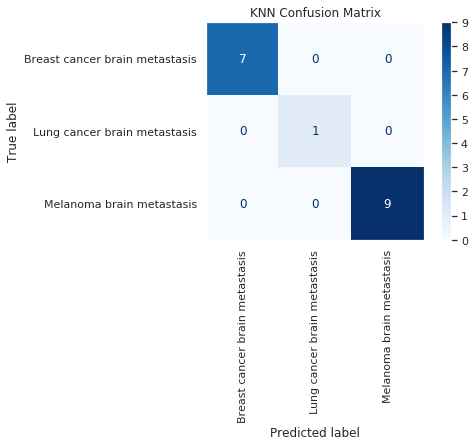

In [204]:
class_names = ['Breast cancer brain metastasis', 
                'Lung cancer brain metastasis', 
                'Melanoma brain metastasis', 
                'Uncertain primary tumor brain metastasis']

disp = plot_confusion_matrix(knn_est, X_test_, Y_test_,
                            display_labels=class_names,
                            cmap=plt.cm.Blues, xticks_rotation='vertical')

disp.ax_.set_title("KNN Confusion Matrix")

print(disp.confusion_matrix)
plt.grid(False)
plt.show()

##### Feature importance

In [205]:
from sklearn.inspection import permutation_importance
results = permutation_importance(knn, X_train_, Y_train_, scoring='accuracy')
knn_importance = results.importances_mean

In [206]:
feature_importances_knn = pd.DataFrame(knn_importance, index =train_methyl_array.beta.columns,
columns=['importance']).sort_values('importance', ascending=False) 

feature_importances_knn = feature_importances_knn[:10]

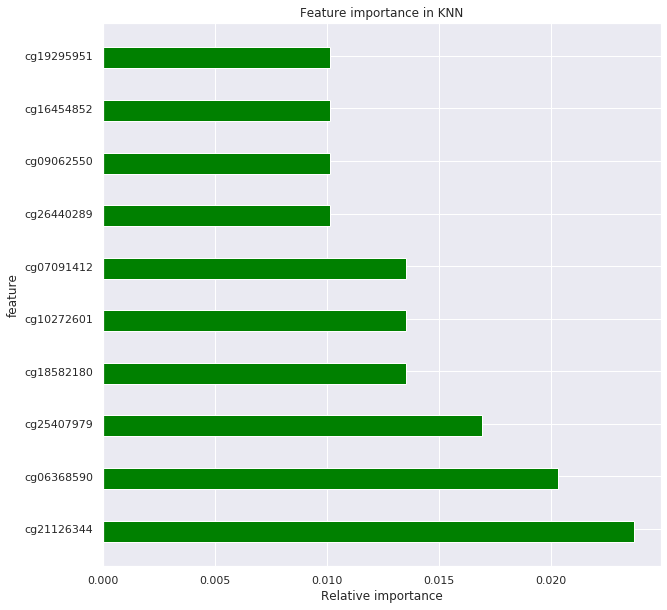

<Figure size 360x360 with 0 Axes>

In [207]:
import matplotlib. pyplot as plt
#modelname.feature_importance
x  = feature_importances_knn.importance
col = feature_importances_knn.importance.index

#plot
fig, ax = plt.subplots() 
width = 0.4 # the width of the bars 
ind = np.arange(len(x)) # the x locations for the groups
ax.barh(ind, x, width, color="green")
ax.set_yticks(ind+width/10)
ax.set_yticklabels(col, minor=False)
plt.title("Feature importance in KNN")
plt.xlabel("Relative importance")
plt.ylabel("feature") 
plt.figure(figsize=(5,5))
fig.set_size_inches(10, 10, forward=True)